# STEP 1: Import Libraries

**Explanation:**

This step loads all required libraries including PyTorch, datasets, plotting, and utilities needed for training and evaluation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# STEP 2: Define Prunable Linear Layer

**Explanation:**

This is the core innovation.
We introduce gate_scores (trainable) and convert them into gates using sigmoid. These gates scale weights and allow pruning.

In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)   # Convert to [0,1]
        pruned_weights = self.weight * gates      # Apply pruning

        return torch.matmul(x, pruned_weights.t()) + self.bias

# STEP 3: Build Neural Network

**Explanation:**

We create a simple feedforward network using our custom prunable layers.
CIFAR-10 images are flattened before passing into the network.

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# STEP 4: Load CIFAR-10 Dataset

**Explanation:**

We normalize the dataset and load it using PyTorch DataLoader for batching.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:12<00:00, 13.7MB/s]


# STEP 5: Sparsity Loss Function

**Explanation:**

We compute L1 norm of all gate values across layers.
This encourages many gates → 0 (pruning).

In [5]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss

# STEP 6: Training Function

**Explanation:**

We combine:

* CrossEntropy Loss
* Sparsity Loss (weighted by λ)

In [6]:
def train_model(lambda_val, epochs=5):
    model = PrunableNet()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)
        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

    return model, train_losses

# STEP 7: Sparsity Calculation

**Explanation:**

We count how many gates are effectively zero (below threshold).

In [7]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += torch.sum(gates < threshold).item()

    return 100 * zero / total

# STEP 8: Model Evaluation

**Explanation:**

Compute classification accuracy on test dataset.

In [8]:
def evaluate(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# STEP 9: Run Experiments with Different λ

**Explanation:**

We test multiple λ values to observe sparsity vs accuracy trade-off.

In [9]:
lambdas = [1e-6, 1e-5, 1e-4]

results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model, losses = train_model(lam)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 1e-06
Epoch 1, Loss: 1931.0973
Epoch 2, Loss: 1683.4636
Epoch 3, Loss: 1545.7805
Epoch 4, Loss: 1441.8894
Epoch 5, Loss: 1352.5963
Lambda: 1e-06, Accuracy: 55.01%, Sparsity: 0.02%

Training with lambda = 1e-05
Epoch 1, Loss: 7030.3442
Epoch 2, Loss: 5318.9560
Epoch 3, Loss: 4209.2508
Epoch 4, Loss: 3498.8185
Epoch 5, Loss: 3031.3363
Lambda: 1e-05, Accuracy: 55.10%, Sparsity: 0.47%

Training with lambda = 0.0001
Epoch 1, Loss: 57522.4824
Epoch 2, Loss: 38522.6199
Epoch 3, Loss: 24862.2963
Epoch 4, Loss: 16421.0486
Epoch 5, Loss: 11431.5840
Lambda: 0.0001, Accuracy: 54.35%, Sparsity: 1.47%


# STEP 10: Plot Results

**Explanation:**

Visualize trade-off between sparsity and accuracy.

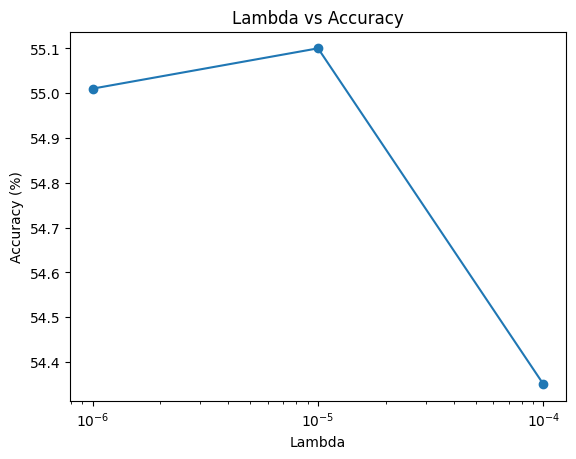

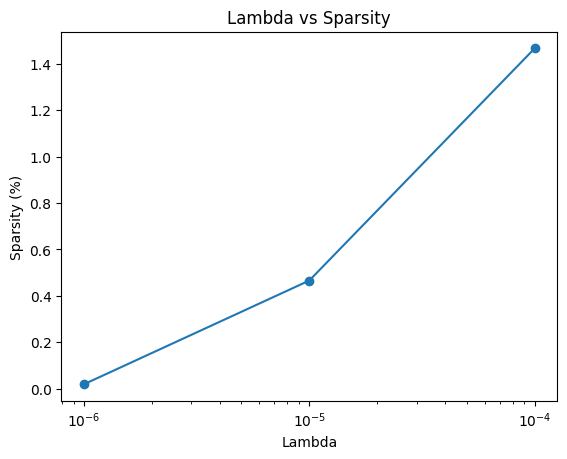

In [10]:
lams = [r[0] for r in results]
accs = [r[1] for r in results]
sparsities = [r[2] for r in results]

plt.figure()
plt.plot(lams, accs, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Accuracy (%)")
plt.title("Lambda vs Accuracy")
plt.xscale('log')
plt.show()

plt.figure()
plt.plot(lams, sparsities, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Sparsity (%)")
plt.title("Lambda vs Sparsity")
plt.xscale('log')
plt.show()

# STEP 11: Confusion Matrix Calculation

**Explanation:**

We collect all predictions and true labels across the test set and compute a confusion matrix. This helps analyze class-wise performance, not just overall accuracy.

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_predictions(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

# STEP 12: Plot Confusion Matrix

**Explanation:**

We visualize the confusion matrix using a heatmap.
Diagonal values → correct predictions, off-diagonal → misclassifications.

In [12]:
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# STEP 13: Gate Heatmap Visualization

**Explanation:**

This visualizes **which weights survived pruning.**
Lower values → pruned connections, higher → important connections.

In [13]:
def plot_gate_heatmap(model, layer_idx=0):
    layers = [m for m in model.modules() if isinstance(m, PrunableLinear)]

    selected_layer = layers[layer_idx]
    gates = torch.sigmoid(selected_layer.gate_scores).detach().cpu().numpy()

    plt.figure(figsize=(10,6))
    sns.heatmap(gates)

    plt.title(f"Gate Heatmap - Layer {layer_idx}")
    plt.xlabel("Input Features")
    plt.ylabel("Neurons")
    plt.show()

# STEP 14: Sparsity Heatmap (Binary Mask)

**Explanation:**

This shows **hard pruning effect** using thresholding.
1 → active weights, 0 → pruned weights.

In [14]:
def plot_binary_mask(model, layer_idx=0, threshold=1e-2):
    layers = [m for m in model.modules() if isinstance(m, PrunableLinear)]

    selected_layer = layers[layer_idx]
    gates = torch.sigmoid(selected_layer.gate_scores).detach().cpu().numpy()

    binary_mask = (gates > threshold).astype(int)

    plt.figure(figsize=(10,6))
    sns.heatmap(binary_mask)

    plt.title(f"Binary Pruning Mask - Layer {layer_idx}")
    plt.xlabel("Input Features")
    plt.ylabel("Neurons")
    plt.show()

# STEP 15: Integrate into Experiment Loop

**Explanation:**

After training each model, we:

* Compute confusion matrix
* Plot heatmap of gates
* Visualize sparsity mask


Training with lambda = 1e-06
Epoch 1, Loss: 1926.2178
Epoch 2, Loss: 1679.9934
Epoch 3, Loss: 1546.8512
Epoch 4, Loss: 1446.3815
Epoch 5, Loss: 1354.0698
Lambda: 1e-06, Accuracy: 53.99%, Sparsity: 0.01%


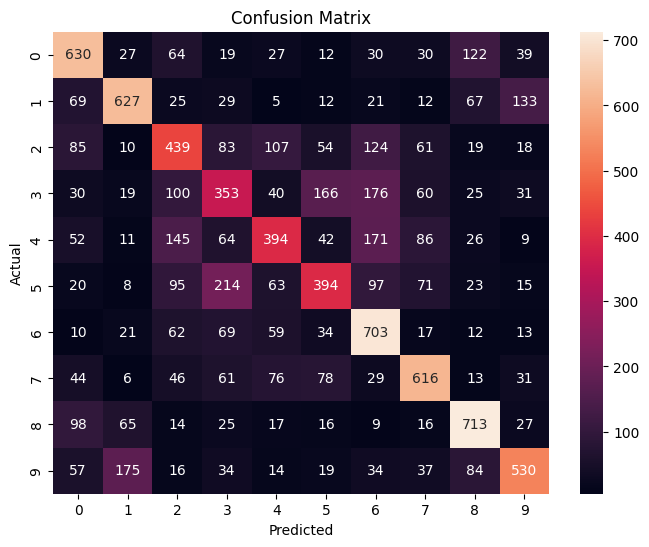

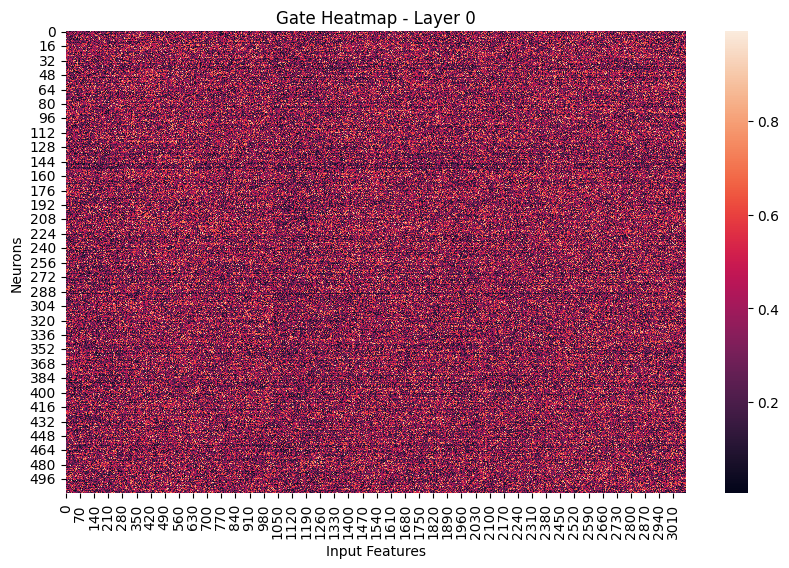

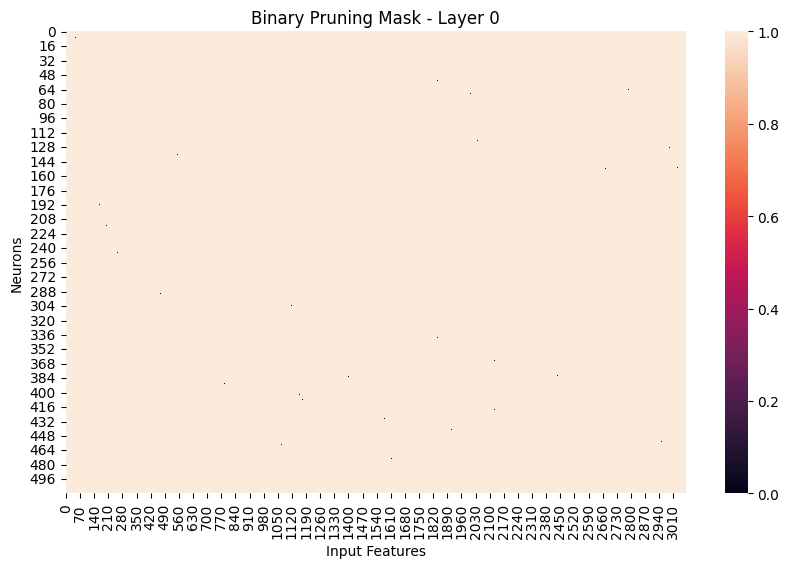


Training with lambda = 1e-05
Epoch 1, Loss: 7030.7253
Epoch 2, Loss: 5303.7392
Epoch 3, Loss: 4198.4769
Epoch 4, Loss: 3489.8154
Epoch 5, Loss: 3016.7590
Lambda: 1e-05, Accuracy: 54.65%, Sparsity: 0.48%


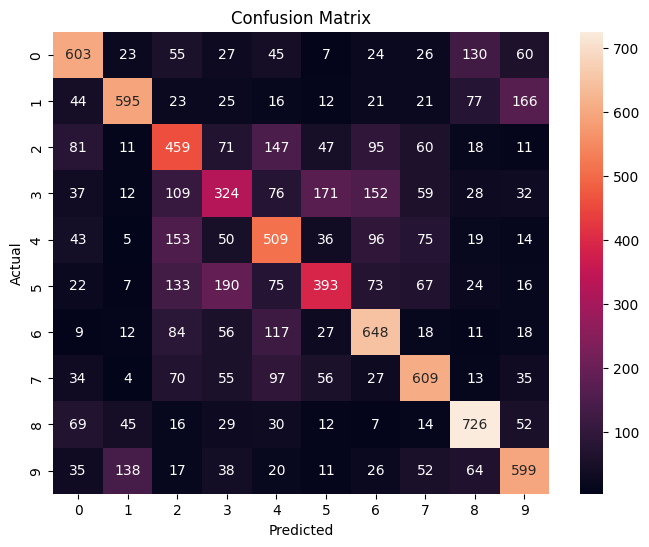

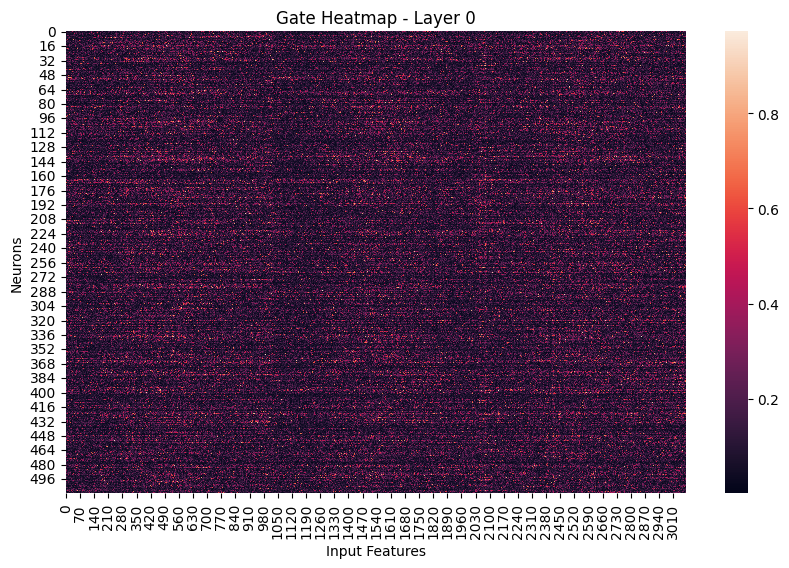

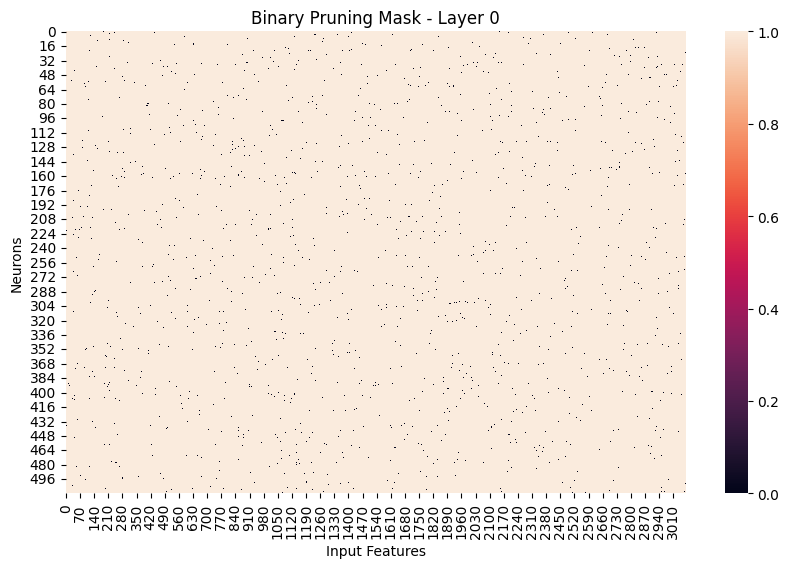


Training with lambda = 0.0001
Epoch 1, Loss: 57489.7753
Epoch 2, Loss: 38493.1730
Epoch 3, Loss: 24844.3463
Epoch 4, Loss: 16411.5364
Epoch 5, Loss: 11423.6307
Lambda: 0.0001, Accuracy: 54.51%, Sparsity: 1.48%


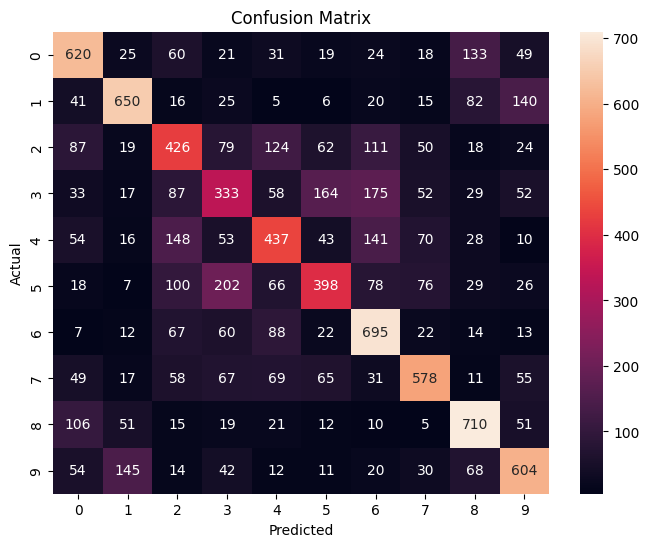

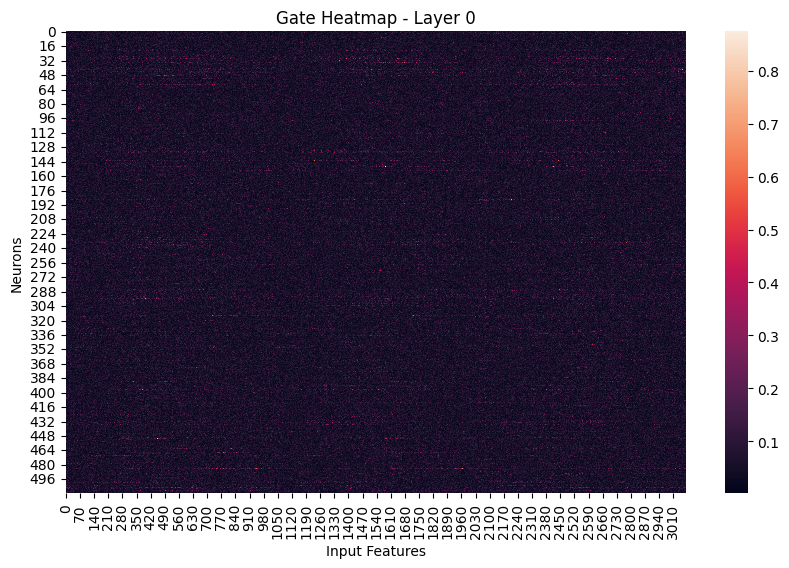

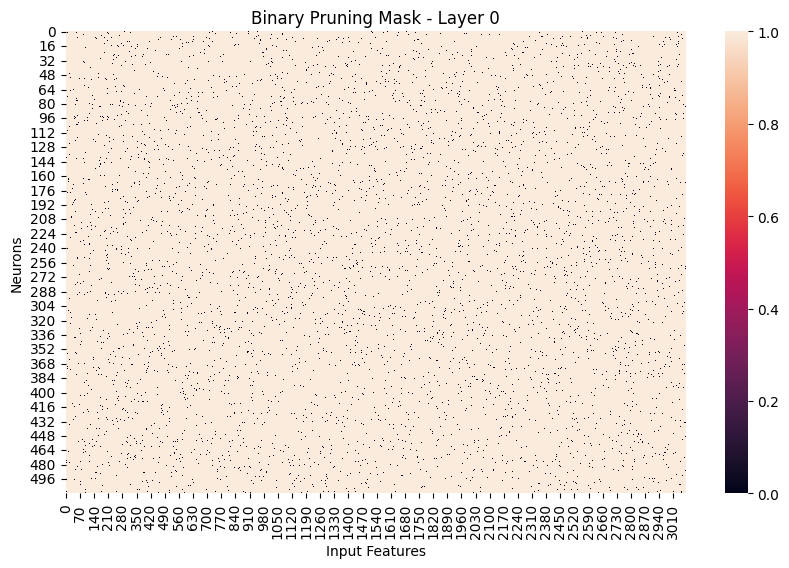

In [15]:
for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model, losses = train_model(lam)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")

    # Confusion Matrix
    labels, preds = get_predictions(model)
    plot_confusion_matrix(labels, preds)

    # Gate Heatmap
    plot_gate_heatmap(model, layer_idx=0)

    # Binary Sparsity Mask
    plot_binary_mask(model, layer_idx=0)